In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import sys, os, time

sys.path.append(os.path.abspath("../src"))
from SegmentationAndLabelingProblem import SegmentationAndLabeling

## Model setup

In [2]:
num_nodes = 6
num_labels = 1

seed = 1234
np.random.seed(seed)

# alpha_dc
A = np.zeros((num_nodes, num_labels))
# A = np.random.uniform(-1, 1, size=(num_nodes, num_labels))
A = np.around(A, 1)

# beta_dc_d'c'
B = np.zeros((num_nodes, num_nodes, num_labels, num_labels))
B[0, 1, :, :] = -1
B[1, 2, :, :] = 1
B[2, 3, :, :] = -1
B[3, 4, :, :] = 1
B[4, 5, :, :] = -1
B[0, 5, :, :] = 1
# print(B)

## Max 2 segments

Segmentation and Labeling Problem initialization:
  Number of nodes:  6
  Number of labels:  1
  Maximum number of segments (+1 for suppressed detections):  3


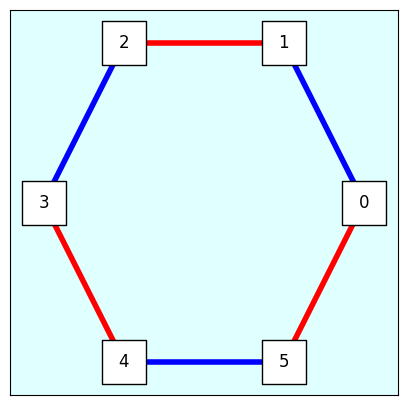

In [3]:
# one-hot encoding requires specifying the maximum number of possible segments (S_max), the optimal number of segments is expected to lie in [1, S_max].
max_num_segments = 2

model = SegmentationAndLabeling(
    num_nodes=num_nodes,
    num_labels=num_labels,
    num_segments=max_num_segments,
    suppress=True,
)

fig = plt.figure(figsize=(5, 5), frameon=False)
ax = fig.add_subplot(1, 1, 1)  # nrows, ncols, index
ax.set_facecolor("lightcyan")
model.draw_graph(
    ax,
    draw_node_labels=False,
    draw_edge_labels=False,
    label_pos=0.3,
    A=A,
    B=B,
)

## CPLEX solution

In [4]:
mdl = model.build_model(A, B, C=100)
mdl.solve()
mdl.print_information()
mdl.print_solution()

Model: Segmentation and Labeling
 - number of variables: 18
   - binary=18, integer=0, continuous=0
 - number of constraints: 0
   - linear=0
 - parameters: defaults
 - objective: minimize quadratic
 - problem type is: MIQP
objective: -2.000
status: OPTIMAL_SOLUTION(2)
  x_0_0_0=1
  x_1_0_0=1
  x_2_0_1=1
  x_3_0_1=1
  x_4_0_0=1
  x_5_0_1=1


Objective:  -2.0


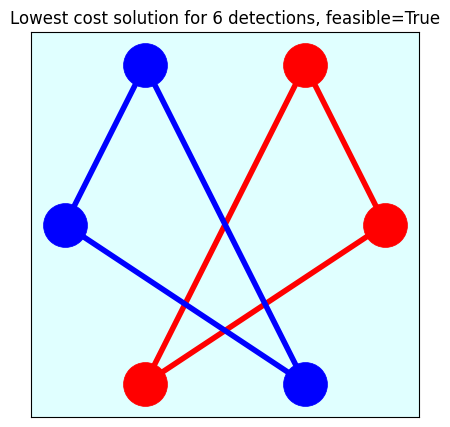

In [5]:
x = np.zeros(mdl.number_of_binary_variables)
for v in mdl.iter_binary_vars():
    x[v.index] = v.solution_value

fig = plt.figure(figsize=(5, 5), frameon=False)
ax = fig.add_subplot(1, 1, 1)  # nrows, ncols, index
ax.set_facecolor("lightcyan")

model.draw_solution(
    ax,
    x,
    node_size=1000,
    width=4,
    alpha=1.0,
)

print("Objective: ", mdl.objective_value)
feas = model.is_valid(x)
plt.title(f"Lowest cost solution for {num_nodes} detections, feasible={feas}")
plt.show()

## Max 4 segments

Segmentation and Labeling Problem initialization:
  Number of nodes:  6
  Number of labels:  1
  Maximum number of segments (+1 for suppressed detections):  5


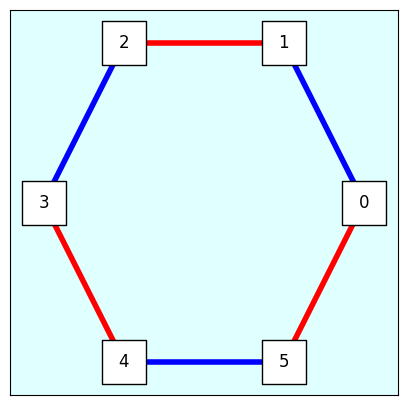

In [6]:
# one-hot encoding requires specifying the maximum number of possible segments (S_max), the optimal number of segments is expected to lie in [1, S_max].
max_num_segments = 4

model = SegmentationAndLabeling(
    num_nodes=num_nodes,
    num_labels=num_labels,
    num_segments=max_num_segments,
    suppress=True,
)

fig = plt.figure(figsize=(5, 5), frameon=False)
ax = fig.add_subplot(1, 1, 1)  # nrows, ncols, index
ax.set_facecolor("lightcyan")
model.draw_graph(
    ax,
    draw_node_labels=False,
    draw_edge_labels=False,
    label_pos=0.3,
    A=A,
    B=B,
)

## CPLEX solution

In [7]:
mdl = model.build_model(A, B, C=100)
mdl.solve()
mdl.print_information()
mdl.print_solution()

Model: Segmentation and Labeling
 - number of variables: 30
   - binary=30, integer=0, continuous=0
 - number of constraints: 0
   - linear=0
 - parameters: defaults
 - objective: minimize quadratic
 - problem type is: MIQP
objective: -3.000
status: OPTIMAL_SOLUTION(2)
  x_0_0_0=1
  x_1_0_0=1
  x_2_0_1=1
  x_3_0_1=1
  x_4_0_2=1
  x_5_0_2=1


Objective:  -3.0


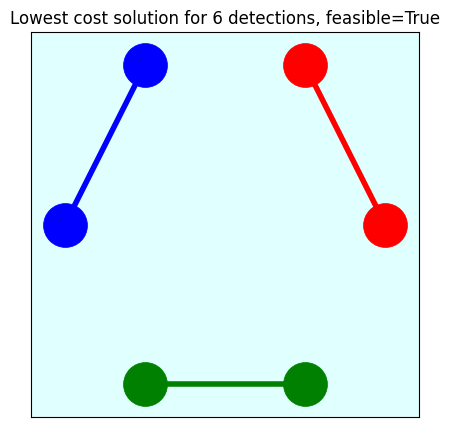

In [8]:
x = np.zeros(mdl.number_of_binary_variables)
for v in mdl.iter_binary_vars():
    x[v.index] = v.solution_value

fig = plt.figure(figsize=(5, 5), frameon=False)
ax = fig.add_subplot(1, 1, 1)  # nrows, ncols, index
ax.set_facecolor("lightcyan")

model.draw_solution(
    ax,
    x,
    node_size=1000,
    width=4,
    alpha=1.0,
)

print("Objective: ", mdl.objective_value)
feas = model.is_valid(x)
plt.title(f"Lowest cost solution for {num_nodes} detections, feasible={feas}")
plt.show()